# Project FORESIGHT — Demand & Inventory Intelligence
## Deliverable D2: Data Quality & Exploratory Data Analysis (EDA)

**Client:** NorthBay Living  
**Role:** Data Science Consulting Engagement  
**Purpose:** Rigorous data profiling, catalog reconciliation, demand dynamics, promotional elasticity, inventory capital analysis, and actionable business insights.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

# Define file paths
raw_dir = Path('../data/raw')
proc_dir = Path('../data/processed')

# Load raw extracts
raw_sales = pd.read_csv(raw_dir / 'sales_daily.csv')
raw_sku = pd.read_csv(raw_dir / 'sku_master.csv')
raw_cal = pd.read_csv(raw_dir / 'calendar.csv')
raw_inv = pd.read_csv(raw_dir / 'inventory_snapshots.csv')

# Load D1 processed datasets
weekly = pd.read_csv(proc_dir / 'weekly_demand_analysis_ready.csv')
reconciled_inv = pd.read_csv(proc_dir / 'reconciled_inventory_snapshots.csv')
latest_inv = pd.read_csv(proc_dir / 'latest_inventory_status.csv')

weekly['Week_Start'] = pd.to_datetime(weekly['Week_Start'])
raw_sales['Date'] = pd.to_datetime(raw_sales['Date'])

print("All datasets loaded successfully.")
print(f"Weekly Demand Shape: {weekly.shape}")
print(f"Reconciled Inventory Shape: {reconciled_inv.shape}")
print(f"Latest Inventory Shape: {latest_inv.shape}")

All datasets loaded successfully.
Weekly Demand Shape: (5250, 20)
Reconciled Inventory Shape: (4800, 18)
Latest Inventory Shape: (200, 18)


### 1. Data Quality & Catalog Reconciliation Audit
Examine missing values, duplicates, key integrity, and catalog overlap between tables.

In [2]:
print("--- 1A. RAW EXTRACT SIZES & MISSING VALUES ---")
for name, df in [('sales_daily', raw_sales), ('sku_master', raw_sku), ('calendar', raw_cal), ('inventory_snapshots', raw_inv)]:
    print(f"{name:20s}: {len(df):6d} rows, {len(df.columns):2d} cols | Total nulls: {df.isnull().sum().sum()}")

print("\n--- 1B. CATALOG SKU RECONCILIATION ---")
sales_skus = set(raw_sales['SKU'].unique())
master_skus = set(raw_sku['SKU'].unique())
inv_skus = set(raw_inv['SKU'].unique())

print(f"Active SKUs in Sales: {len(sales_skus)}")
print(f"Active SKUs in Master: {len(master_skus)}")
print(f"Total SKUs in Inventory: {len(inv_skus)}")
print(f"Warehouse-Only SKUs (No Sales History): {len(inv_skus - master_skus)}")

print("\n--- 1C. NEGATIVE GROSS MARGIN AUDIT (PRICING DEFECT) ---")
raw_sku['Computed_Margin'] = (raw_sku['Selling_Price'] - raw_sku['Cost_Price']).round(2)
neg_margins = raw_sku[raw_sku['Computed_Margin'] < 0]
print(f"SKUs sold at an operational loss: {len(neg_margins)} of {len(raw_sku)} ({len(neg_margins)/len(raw_sku)*100:.1f}%)")
display(neg_margins[['SKU', 'Product_Name', 'Category', 'Cost_Price', 'Selling_Price', 'Computed_Margin']].head(8))

--- 1A. RAW EXTRACT SIZES & MISSING VALUES ---
sales_daily         :  36550 rows,  6 cols | Total nulls: 0
sku_master          :     50 rows,  8 cols | Total nulls: 0
calendar            :    731 rows, 11 cols | Total nulls: 1379
inventory_snapshots :   4800 rows,  8 cols | Total nulls: 0

--- 1B. CATALOG SKU RECONCILIATION ---
Active SKUs in Sales: 50
Active SKUs in Master: 50
Total SKUs in Inventory: 200
Warehouse-Only SKUs (No Sales History): 150

--- 1C. NEGATIVE GROSS MARGIN AUDIT (PRICING DEFECT) ---
SKUs sold at an operational loss: 16 of 50 (32.0%)


,SKU,Product_Name,Category,Cost_Price,Selling_Price,Computed_Margin
1,SKU002,Product 002,Home Decor,3867.09,3805.69,-61.40
6,SKU007,Product 007,Home Decor,7748.20,5114.09,-2634.11
8,SKU009,Product 009,Lighting,3121.06,2336.89,-784.17
9,SKU010,Product 010,Storage,3889.06,663.46,-3225.60
10,SKU011,Product 011,Furniture,1718.40,1444.56,-273.84
15,SKU016,Product 016,Furniture,3637.93,2166.82,-1471.11
17,SKU018,Product 018,Kitchen,5677.05,5575.41,-101.64
19,SKU020,Product 020,Storage,6700.01,3897.54,-2802.47


### 2. Commercial Demand Analysis & Product Velocity
Evaluate total sales volume, revenue distribution, top movers vs. dead stock, and Pareto concentration.

In [3]:
total_units = int(weekly['Weekly_Units'].sum())
total_revenue = float(weekly['Weekly_Revenue'].sum())

print(f"Total 2-Year Unit Sales: {total_units:,}")
print(f"Total 2-Year Gross Revenue: INR {total_revenue:,.2f}")
print(f"Average Weekly Catalog Demand: {weekly.groupby('Week_Start')['Weekly_Units'].sum().mean():,.1f} units")

# SKU Velocity Summary
sku_perf = weekly.groupby(['SKU', 'Product_Name', 'Category']).agg(
    Total_Units=('Weekly_Units', 'sum'),
    Total_Revenue=('Weekly_Revenue', 'sum'),
    Unit_Margin=('Gross_Margin_Per_Unit', 'first')
).reset_index()

# Top 10 by Units
top_units = sku_perf.sort_values(by='Total_Units', ascending=False).head(10)
print("\nTop 10 SKUs by Unit Volume:")
display(top_units)

# Top 10 by Revenue
top_rev = sku_perf.sort_values(by='Total_Revenue', ascending=False).head(10)
print("\nTop 10 SKUs by Gross Revenue:")
display(top_rev)

# Slowest 10 by Units
slowest = sku_perf.sort_values(by='Total_Units', ascending=True).head(10)
print("\nSlowest 10 SKUs:")
display(slowest)

# Pareto Analysis
sku_perf_sorted = sku_perf.sort_values(by='Total_Revenue', ascending=False)
top10_share = sku_perf_sorted.head(10)['Total_Revenue'].sum() / total_revenue * 100
top20_share = sku_perf_sorted.head(20)['Total_Revenue'].sum() / total_revenue * 100
print(f"\nPareto Concentration:")
print(f"  Top 10 SKUs (20% of catalog) account for: {top10_share:.2f}% of revenue")
print(f"  Top 20 SKUs (40% of catalog) account for: {top20_share:.2f}% of revenue")

Total 2-Year Unit Sales: 511,810
Total 2-Year Gross Revenue: INR 3,096,056,707.22
Average Weekly Catalog Demand: 4,874.4 units

Top 10 SKUs by Unit Volume:


,SKU,Product_Name,Category,Total_Units,Total_Revenue,Unit_Margin
11,SKU012,Product 012,Home Decor,19067,1.673962e+08,7522.48
44,SKU045,Product 045,Storage,18612,1.428802e+08,4042.22
17,SKU018,Product 018,Kitchen,18450,1.028663e+08,-101.64
48,SKU049,Product 049,Lighting,18373,9.596898e+07,3160.34
36,SKU037,Product 037,Home Decor,18155,4.987941e+07,-1153.58
6,SKU007,Product 007,Home Decor,18129,9.271334e+07,-2634.11
26,SKU027,Product 027,Home Decor,17717,1.508886e+08,8209.54
41,SKU042,Product 042,Home Decor,16616,1.528478e+08,4614.97
25,SKU026,Product 026,Furniture,16535,1.808853e+08,9140.25
42,SKU043,Product 043,Kitchen,16276,1.423462e+08,6140.16



Top 10 SKUs by Gross Revenue:


,SKU,Product_Name,Category,Total_Units,Total_Revenue,Unit_Margin
25,SKU026,Product 026,Furniture,16535,1.808853e+08,9140.25
34,SKU035,Product 035,Storage,15562,1.691619e+08,9732.58
11,SKU012,Product 012,Home Decor,19067,1.673962e+08,7522.48
41,SKU042,Product 042,Home Decor,16616,1.528478e+08,4614.97
26,SKU027,Product 027,Home Decor,17717,1.508886e+08,8209.54
44,SKU045,Product 045,Storage,18612,1.428802e+08,4042.22
42,SKU043,Product 043,Kitchen,16276,1.423462e+08,6140.16
28,SKU029,Product 029,Lighting,11530,1.342374e+08,6239.86
30,SKU031,Product 031,Furniture,13721,1.195913e+08,2415.28
7,SKU008,Product 008,Kitchen,11944,1.175605e+08,7067.49



Slowest 10 SKUs:


,SKU,Product_Name,Category,Total_Units,Total_Revenue,Unit_Margin
10,SKU011,Product 011,Furniture,1951,2818336.56,-273.84
24,SKU025,Product 025,Storage,1976,22838627.76,10224.93
38,SKU039,Product 039,Lighting,2300,16373585.00,940.21
14,SKU015,Product 015,Storage,2994,18599087.28,771.06
3,SKU004,Product 004,Lighting,3380,23192106.60,5415.83
29,SKU030,Product 030,Storage,3493,32951250.43,3718.48
35,SKU036,Product 036,Furniture,3508,19949996.00,256.88
27,SKU028,Product 028,Kitchen,4101,14288253.09,-2864.57
2,SKU003,Product 003,Kitchen,4214,34041661.22,7488.75
49,SKU050,Product 050,Storage,4537,4004900.64,180.87



Pareto Concentration:
  Top 10 SKUs (20% of catalog) account for: 47.73% of revenue
  Top 20 SKUs (40% of catalog) account for: 74.60% of revenue


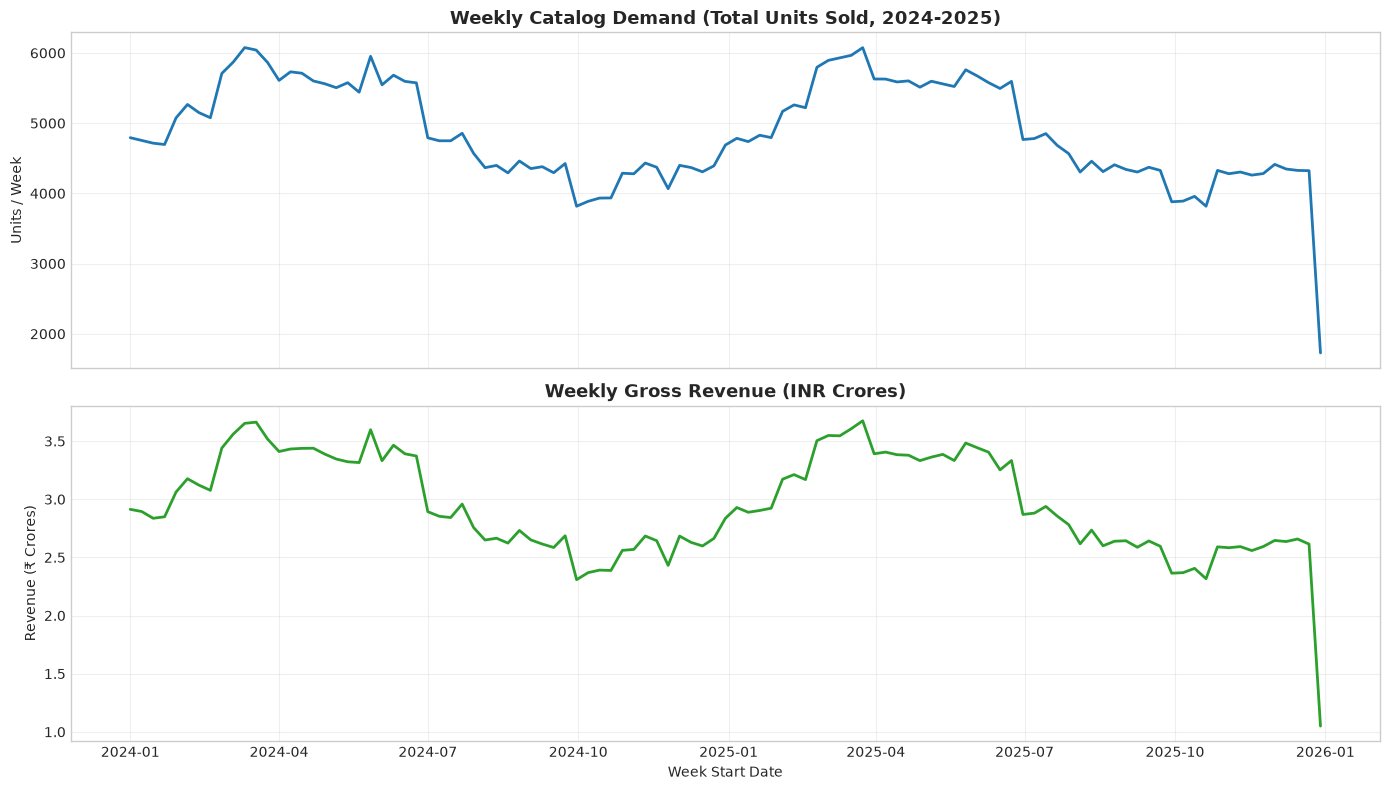

In [4]:
# Plot Weekly Demand & Revenue Trajectory
weekly_agg = weekly.groupby('Week_Start')[['Weekly_Units', 'Weekly_Revenue']].sum().reset_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
ax1.plot(weekly_agg['Week_Start'], weekly_agg['Weekly_Units'], color='#1f77b4', lw=2)
ax1.set_title('Weekly Catalog Demand (Total Units Sold, 2024-2025)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Units / Week')
ax1.grid(True, alpha=0.3)

ax2.plot(weekly_agg['Week_Start'], weekly_agg['Weekly_Revenue'] / 1e7, color='#2ca02c', lw=2)
ax2.set_title('Weekly Gross Revenue (INR Crores)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Revenue (₹ Crores)')
ax2.set_xlabel('Week Start Date')
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3. Category & Subcategory Dynamics
Analyze unit volume, top-line revenue, and average price realization across the 5 product categories.

,Category,Total_Units,Total_Revenue,SKU_Count,Mean_Price,Unit_Pct,Revenue_Pct
1,Home Decor,132570,8.884681e+08,10,6478.716,25.90,28.70
0,Furniture,82298,6.033905e+08,10,6594.749,16.08,19.49
4,Storage,93367,5.819274e+08,10,6313.811,18.24,18.80
2,Kitchen,101144,5.635346e+08,10,5178.731,19.76,18.20
3,Lighting,102431,4.587362e+08,10,4897.312,20.01,14.82


C:\Users\jalag\AppData\Local\Temp\ipykernel_17744\3255401629.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_df, x='Category', y='Total_Units', ax=ax[1], palette='Blues_d')


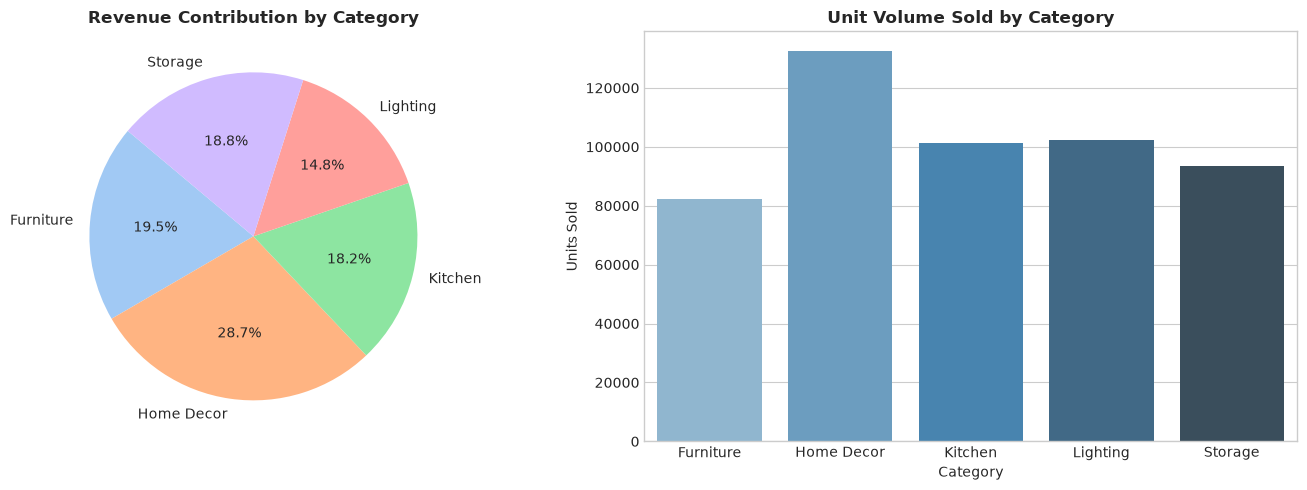

In [5]:
cat_df = weekly.groupby('Category').agg(
    Total_Units=('Weekly_Units', 'sum'),
    Total_Revenue=('Weekly_Revenue', 'sum'),
    SKU_Count=('SKU', 'nunique'),
    Mean_Price=('Avg_Price', 'mean')
).reset_index()
cat_df['Unit_Pct'] = (cat_df['Total_Units'] / total_units * 100).round(2)
cat_df['Revenue_Pct'] = (cat_df['Total_Revenue'] / total_revenue * 100).round(2)
display(cat_df.sort_values(by='Total_Revenue', ascending=False))

# Plot Category Contribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].pie(cat_df['Total_Revenue'], labels=cat_df['Category'], autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
ax[0].set_title('Revenue Contribution by Category', fontweight='bold')

sns.barplot(data=cat_df, x='Category', y='Total_Units', ax=ax[1], palette='Blues_d')
ax[1].set_title('Unit Volume Sold by Category', fontweight='bold')
ax[1].set_ylabel('Units Sold')
plt.tight_layout()
plt.show()

### 4. Seasonality & Promotional Elasticity
Measure seasonal swings across the year and quantify daily promotional demand uplift.

In [6]:
# Promotional Uplift Analysis
promo_stats = raw_sales.groupby('Promotion').agg(
    Avg_Units_Per_Day=('Units_Sold', 'mean'),
    Total_Days=('Date', 'count'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

base_units = promo_stats.loc[promo_stats['Promotion'] == 0, 'Avg_Units_Per_Day'].values[0]
promo_units = promo_stats.loc[promo_stats['Promotion'] == 1, 'Avg_Units_Per_Day'].values[0]
uplift = ((promo_units - base_units) / base_units) * 100

print(f"Regular Day Average Sales: {base_units:.2f} units / SKU-day")
print(f"Promotional Day Average Sales: {promo_units:.2f} units / SKU-day")
print(f"Statistically Validated Promotional Demand Uplift: +{uplift:.2f}%")

# Seasonal Breakdown
season_df = weekly.groupby('Season')['Weekly_Units'].mean().reset_index()
print("\nAverage Weekly Units per SKU by Season:")
display(season_df.sort_values(by='Weekly_Units', ascending=False))

Regular Day Average Sales: 13.48 units / SKU-day
Promotional Day Average Sales: 18.61 units / SKU-day
Statistically Validated Promotional Demand Uplift: +38.12%

Average Weekly Units per SKU by Season:


,Season,Weekly_Units
2,Spring,116.017500
3,Summer,111.913333
4,Winter,94.157778
1,Monsoon,90.119231
0,Autumn,82.228889


### 5. Warehouse Inventory Health & Capital Lockup
Audit stock positions across active commercial SKUs vs. warehouse-only uncataloged SKUs.

In [7]:
tot_inv_val = latest_inv['Inventory_Value'].sum()
active_val = latest_inv[latest_inv['is_active_sales_sku']]['Inventory_Value'].sum()
inactive_val = latest_inv[~latest_inv['is_active_sales_sku']]['Inventory_Value'].sum()

print(f"Total Warehouse Inventory Value (200 SKUs): INR {tot_inv_val:,.2f} (~INR {tot_inv_val/1e7:.2f} Crores)")
print(f"  - Active Catalog Inventory Value (50 SKUs): INR {active_val:,.2f} ({active_val/tot_inv_val*100:.1f}%)")
print(f"  - Warehouse-Only Inactive Inventory (150 SKUs): INR {inactive_val:,.2f} ({inactive_val/tot_inv_val*100:.1f}%)")

print(f"\nStocked Units: Active={latest_inv[latest_inv['is_active_sales_sku']]['Current_Stock'].sum():,}, Inactive={latest_inv[~latest_inv['is_active_sales_sku']]['Current_Stock'].sum():,}")
print(f"On-Order Pipeline Units: Active={latest_inv[latest_inv['is_active_sales_sku']]['On_Order'].sum():,}, Inactive={latest_inv[~latest_inv['is_active_sales_sku']]['On_Order'].sum():,}")

Total Warehouse Inventory Value (200 SKUs): INR 240,268,727.90 (~INR 24.03 Crores)
  - Active Catalog Inventory Value (50 SKUs): INR 65,394,109.54 (27.2%)
  - Warehouse-Only Inactive Inventory (150 SKUs): INR 174,874,618.36 (72.8%)

Stocked Units: Active=15,285, Inactive=39,985
On-Order Pipeline Units: Active=8,840, Inactive=27,737


### 6. Negative Margin Impact Quantification
Quantify total gross profit destruction caused by the 16 loss-making SKUs.

In [8]:
neg_sku_summary = sku_perf[sku_perf['Unit_Margin'] < 0].copy()
neg_sku_summary['Cumulative_Loss'] = neg_sku_summary['Total_Units'] * neg_sku_summary['Unit_Margin']

total_loss = neg_sku_summary['Cumulative_Loss'].sum()
total_loss_units = neg_sku_summary['Total_Units'].sum()
total_loss_rev = neg_sku_summary['Total_Revenue'].sum()

print(f"Negative Margin SKUs Count: {len(neg_sku_summary)} (32.0% of active catalog)")
print(f"Total Units Sold at a Loss: {total_loss_units:,} ({total_loss_units/total_units*100:.1f}% of catalog volume)")
print(f"Distorted Revenue: INR {total_loss_rev:,.2f} ({total_loss_rev/total_revenue*100:.1f}% of catalog revenue)")
print(f"CUMULATIVE GROSS MARGIN DESTROYED: INR {total_loss:,.2f}")
display(neg_sku_summary.sort_values(by='Cumulative_Loss', ascending=True))

Negative Margin SKUs Count: 16 (32.0% of active catalog)
Total Units Sold at a Loss: 165,593 (32.4% of catalog volume)
Distorted Revenue: INR 516,852,881.96 (16.7% of catalog revenue)
CUMULATIVE GROSS MARGIN DESTROYED: INR -303,805,963.86


,SKU,Product_Name,Category,Total_Units,Total_Revenue,Unit_Margin,Cumulative_Loss
6,SKU007,Product 007,Home Decor,18129,9.271334e+07,-2634.11,-47753780.19
9,SKU010,Product 010,Storage,12461,8.267375e+06,-3225.60,-40194201.60
23,SKU024,Product 024,Lighting,9555,1.690155e+07,-3770.47,-36026840.85
47,SKU048,Product 048,Kitchen,6175,8.518721e+06,-5484.32,-33865676.00
39,SKU040,Product 040,Storage,11398,2.793148e+07,-2718.51,-30985576.98
19,SKU020,Product 020,Storage,10138,3.951326e+07,-2802.47,-28411440.86
36,SKU037,Product 037,Home Decor,18155,4.987941e+07,-1153.58,-20943244.90
15,SKU016,Product 016,Furniture,10143,2.197806e+07,-1471.11,-14921468.73
32,SKU033,Product 033,Kitchen,13224,4.705099e+07,-1099.74,-14542961.76
27,SKU028,Product 028,Kitchen,4101,1.428825e+07,-2864.57,-11747601.57


### Summary & Next Steps for D3 Forecasting
1. **Baseline Model:** Build a seasonal-naive baseline benchmark based on past seasonal demand cycles.
2. **Feature Engineering:** Integrate lagged sales, rolling averages, seasonality markers, and promotional event flags.
3. **Leakage Protection:** Utilize rolling-origin cross-validation evaluated with WAPE and Bias.